<a href="https://colab.research.google.com/github/fknbtrd/netology_homework/blob/main/%D0%94%D1%80%D0%B5%D0%B2%D0%BE%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn import tree

In [2]:
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Первичная проверка и нормализация

In [3]:
df.info()
df.isnull().sum()
scaler = MinMaxScaler()

df['MedInc'] = scaler.fit_transform(df[['MedInc']])

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,0.539668,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,0.538027,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,0.466028,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,0.354699,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,0.230776,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Разделение данных

In [4]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Линейная регрессия

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

In [6]:
print("Линейная регрессия")

print("Score train:", lr.score(X_train, y_train))
print("Score test:", lr.score(X_test, y_test))

print("RMSE train:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("RMSE test:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Линейная регрессия
Score train: 0.6125511913966952
Score test: 0.5757877060324506
RMSE train: 0.7196757085831574
RMSE test: 0.7455813830127765


Дерево решений

In [7]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
y_train_pred_tree = tree_model.predict(X_train)
y_test_pred_tree = tree_model.predict(X_test)

In [8]:
print("Дерево решений")

print("Score train:", tree_model.score(X_train, y_train))
print("Score test:", tree_model.score(X_test, y_test))

print("RMSE train:", np.sqrt(mean_squared_error(y_train, y_train_pred_tree)))
print("RMSE test:", np.sqrt(mean_squared_error(y_test, y_test_pred_tree)))

Дерево решений
Score train: 1.0
Score test: 0.622075845135081
RMSE train: 3.218325866275131e-16
RMSE test: 0.7037294974840077


Визуализация дерева решений

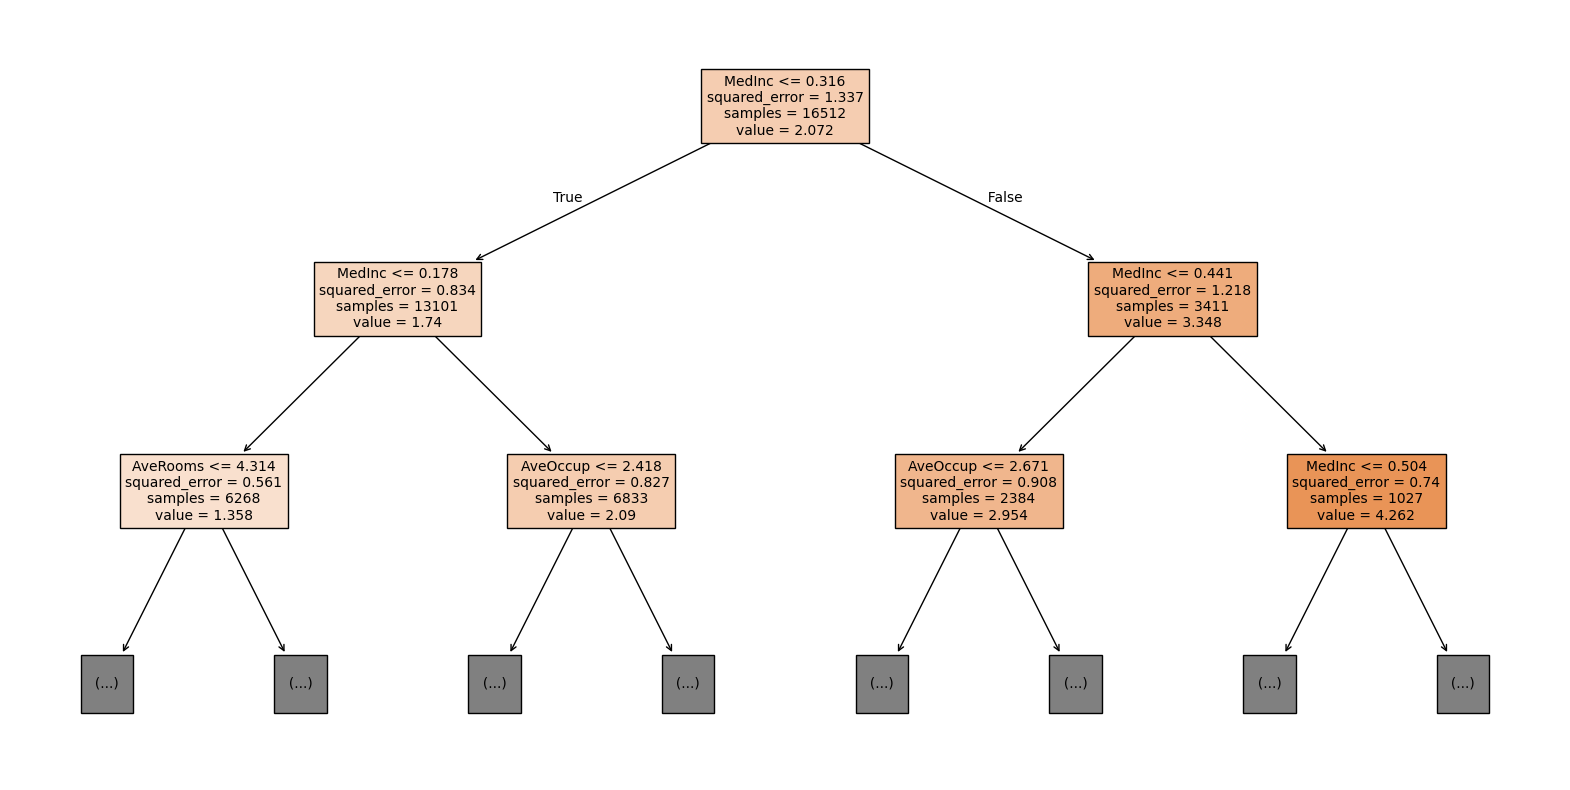

In [9]:
plt.figure(figsize=(20,10))

tree.plot_tree(
    tree_model,
    max_depth=2,
    feature_names=X.columns,
    filled=True,
    fontsize=10
)

plt.show()

Оптимизация глубины дерева

In [10]:
tree_model2 = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model2.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [11]:
y_train_pred_tree2 = tree_model2.predict(X_train)
y_test_pred_tree2 = tree_model2.predict(X_test)

print("Оптимизированное дерево")

print("Score train:", tree_model2.score(X_train, y_train))
print("Score test:", tree_model2.score(X_test, y_test))

print("RMSE train:", np.sqrt(mean_squared_error(y_train, y_train_pred_tree2)))
print("RMSE test:", np.sqrt(mean_squared_error(y_test, y_test_pred_tree2)))

Оптимизированное дерево
Score train: 0.6376786573648903
Score test: 0.5997321244428706
RMSE train: 0.6959477541460324
RMSE test: 0.7242338143386247


Оптимизация ещё одного параметра: min_samples_split

In [12]:
tree_model3 = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

tree_model3.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_split=20, random_state=42)

In [13]:
y_train_pred_tree3 = tree_model3.predict(X_train)
y_test_pred_tree3 = tree_model3.predict(X_test)

print("Дерево с дополнительной оптимизацией")

print("Score train:", tree_model3.score(X_train, y_train))
print("Score test:", tree_model3.score(X_test, y_test))

print("RMSE train:", np.sqrt(mean_squared_error(y_train, y_train_pred_tree3)))
print("RMSE test:", np.sqrt(mean_squared_error(y_test, y_test_pred_tree3)))

Дерево с дополнительной оптимизацией
Score train: 0.6376786573648903
Score test: 0.5997321244428706
RMSE train: 0.6959477541460324
RMSE test: 0.7242338143386247


Сравнение моделей

In [14]:
results = pd.DataFrame({
    'Модель': [
        'Линейная регрессия',
        'Дерево решений',
        'Дерево max_depth=5',
        'Дерево max_depth=5 + min_samples_split=20'
    ],

    'Score test': [
        lr.score(X_test, y_test),
        tree_model.score(X_test, y_test),
        tree_model2.score(X_test, y_test),
        tree_model3.score(X_test, y_test)
    ]
})

results

,Модель,Score test
0,Линейная регрессия,0.575788
1,Дерево решений,0.622076
2,Дерево max_depth=5,0.599732
3,Дерево max_depth=5 + min_samples_split=20,0.599732


Выводы:

1. Обучена модель линейной регрессии.
Модель показала стабильный результат, но качество предсказаний оказалось ограниченным.

2. Обучено дерево решений.
Дерево решений показало более высокую точность на обучающей выборке,
но столкнуличь с переобучением.

3. Для уменьшения переобучения была ограничена глубина дерева (max_depth) и изменен параметр min_samples_split.

6. После оптимизации качество модели на тестовой выборке улучшилось.


Вывод:
Линейная регрессия лучше подходит для простых линейных зависимостей.
Дерево решений лучше улавливает сложные зависимости,
но может переобучаться.

Плюсы линейной регрессии:
- хорошая интерпретируемость

Минусы:
- плохо работает со сложными зависимостями

Плюсы дерева решений:
- умеет находить сложные закономерности

Минусы:
- склонность к переобучению
- нестабильность при изменении данных